In [6]:
# Cell 1: Imports & Setup
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import copy
import os

# Import the core pruning algorithm (make sure p_rigidum_inspired_pruning.py is in the current directory)
try:
    from p_rigidum_inspired_pruning import (
        CNN,
        train_epoch,
        evaluate,
        p_rigidum_prune_indices,
        apply_pruning
    )
except ImportError:
    raise ImportError(
        "Please place p_rigidum_inspired_pruning.py in the current working directory."
    )

# Device and random seed
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)
print(f"Using device: {device}")

Using device: cpu


In [7]:
# Cell 2: Hyperparameters & Data Loading
BATCH_SIZE = 64
PRUNE_RATIO = 0.4          # pruning ratio (0~1)
LEARNING_RATE = 0.001
EPOCHS_BASELINE = 5
EPOCHS_FINETUNE = 5

# Data preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_data = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_data  = datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Training set size: {len(train_data)}, Test set size: {len(test_data)}")

Training set size: 60000, Test set size: 10000


In [8]:
# Cell 3: Instantiate Baseline Model
baseline = CNN().to(device)
print(baseline)
print(f"Number of trainable parameters: {sum(p.numel() for p in baseline.parameters() if p.requires_grad)}")

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (gap): AdaptiveAvgPool2d(output_size=(7, 7))
  (fc1): Linear(in_features=12544, out_features=512, bias=True)
  (drop): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)
Number of trainable paramete

In [9]:
# Cell 4: Train Baseline
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=LEARNING_RATE)

train_accs, test_accs = [], []

for epoch in range(1, EPOCHS_BASELINE + 1):
    train_epoch(baseline, train_loader, optimizer, criterion)
    train_acc = evaluate(baseline, train_loader)
    test_acc  = evaluate(baseline, test_loader)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    print(f"Epoch {epoch:2d}: Train Acc = {train_acc:.2f}%, Test Acc = {test_acc:.2f}%")

baseline_test_acc = test_accs[-1]
print(f"\nFinal baseline test accuracy: {baseline_test_acc:.2f}%")

Epoch  1: Train Acc = 98.25%, Test Acc = 98.23%
Epoch  2: Train Acc = 98.51%, Test Acc = 98.19%
Epoch  3: Train Acc = 99.47%, Test Acc = 99.25%
Epoch  4: Train Acc = 98.79%, Test Acc = 98.37%
Epoch  5: Train Acc = 99.58%, Test Acc = 99.28%

Final baseline test accuracy: 99.28%


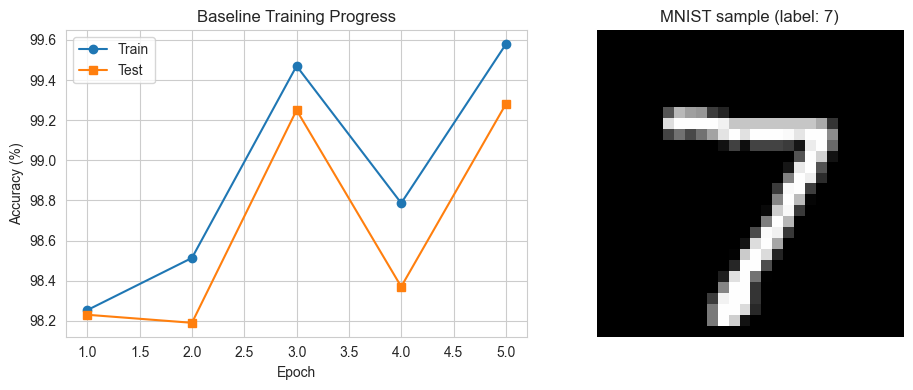

In [16]:
# Cell 5: Visualize Training Curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS_BASELINE+1), train_accs, 'o-', label='Train')
plt.plot(range(1, EPOCHS_BASELINE+1), test_accs, 's-', label='Test')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Baseline Training Progress')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
# Display a random test image
img, label = test_data[0]
plt.imshow(img.squeeze(), cmap='gray')
plt.title(f'MNIST sample (label: {label})')
plt.axis('off')

plt.tight_layout()
plt.show()

In [17]:
# Cell 6: Perform P. rigidum-inspired Pruning
print(f"Pruning ratio: {PRUNE_RATIO*100:.0f}%")
keep_masks = p_rigidum_prune_indices(baseline, test_loader, prune_ratio=PRUNE_RATIO)

# Print the number of kept channels per layer
print("Kept channels per layer:")
for i, mask in enumerate(keep_masks):
    print(f"  Conv{i+1}: {len(mask)} / {32 * (2**i)}")

pruned_model = apply_pruning(baseline, keep_masks)
print(f"\nNumber of parameters after pruning: {sum(p.numel() for p in pruned_model.parameters() if p.requires_grad)}")

Pruning ratio: 40%
Kept channels per layer:
  Conv1: 19 / 32
  Conv2: 38 / 64
  Conv3: 76 / 128
  Conv4: 153 / 256

Number of parameters after pruning: 3982277


In [20]:
# Cell 7: Fine-tune the Pruned Model
optimizer_ft = optim.Adam(pruned_model.parameters(), lr=LEARNING_RATE * 0.1)
print("Starting fine-tuning...")
for epoch in range(1, EPOCHS_FINETUNE + 1):
    train_epoch(pruned_model, train_loader, optimizer_ft, criterion)
    test_acc = evaluate(pruned_model, test_loader)
    print(f"  Fine-tune Epoch {epoch}: Test Acc = {test_acc:.2f}%")

pruned_test_acc = evaluate(pruned_model, test_loader)
print(f"\nFinal pruned model test accuracy: {pruned_test_acc:.2f}%")

Starting fine-tuning...
  Fine-tune Epoch 1: Test Acc = 99.46%
  Fine-tune Epoch 2: Test Acc = 99.34%
  Fine-tune Epoch 3: Test Acc = 99.46%
  Fine-tune Epoch 4: Test Acc = 99.46%
  Fine-tune Epoch 5: Test Acc = 99.46%

Final pruned model test accuracy: 99.46%


In [21]:
# Cell 8: Compare Results
print("="*40)
print(f"Baseline accuracy : {baseline_test_acc:.2f}%")
print(f"Pruned accuracy   : {pruned_test_acc:.2f}%")
print(f"Accuracy drop     : {baseline_test_acc - pruned_test_acc:.2f}%")
print("="*40)

Baseline accuracy : 99.28%
Pruned accuracy   : 99.46%
Accuracy drop     : -0.18%


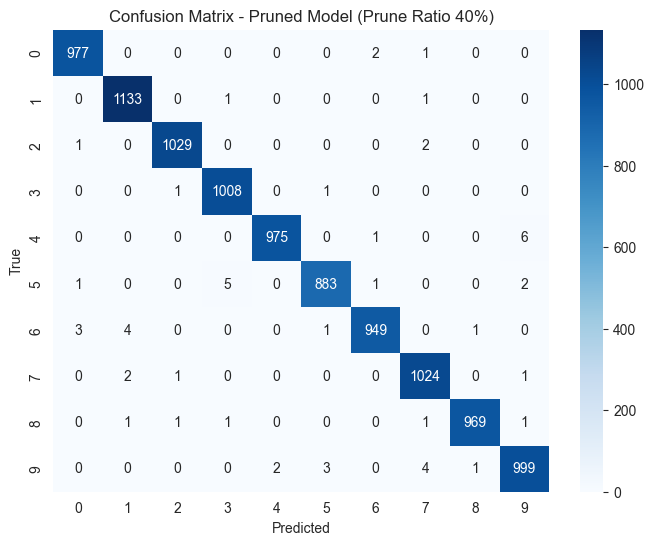

In [22]:
# Cell 9: Confusion Matrix for Pruned Model
def get_predictions(model, loader):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            _, pred = output.max(1)
            all_preds.extend(pred.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
    return all_targets, all_preds

targets, preds = get_predictions(pruned_model, test_loader)
cm = confusion_matrix(targets, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title(f'Confusion Matrix - Pruned Model (Prune Ratio {PRUNE_RATIO*100:.0f}%)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()